In [1]:
import pandas as pd
df = pd.read_csv("~/Downloads/alzheimer.csv")
print(df.head())

         Group M/F  Age  EDUC  SES  MMSE  CDR  eTIV   nWBV    ASF
0  Nondemented   M   87    14  2.0  27.0  0.0  1987  0.696  0.883
1  Nondemented   M   88    14  2.0  30.0  0.0  2004  0.681  0.876
2     Demented   M   75    12  NaN  23.0  0.5  1678  0.736  1.046
3     Demented   M   76    12  NaN  28.0  0.5  1738  0.713  1.010
4     Demented   M   80    12  NaN  22.0  0.5  1698  0.701  1.034


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import KNNImputer
import numpy as np

In [9]:
knn = KNeighborsClassifier(n_neighbors=5)
imputer = KNNImputer(
    missing_values=np.nan,
    n_neighbors=5,
    weights='uniform',
    metric='nan_euclidean',
    add_indicator=False,
    keep_empty_features=False
)

## Contar nulos

In [18]:
df.isna().sum()

Group     0
M/F       0
Age       0
EDUC      0
SES      19
MMSE      2
CDR       0
eTIV      0
nWBV      0
ASF       0
dtype: int64

## Count plot variables categoricas

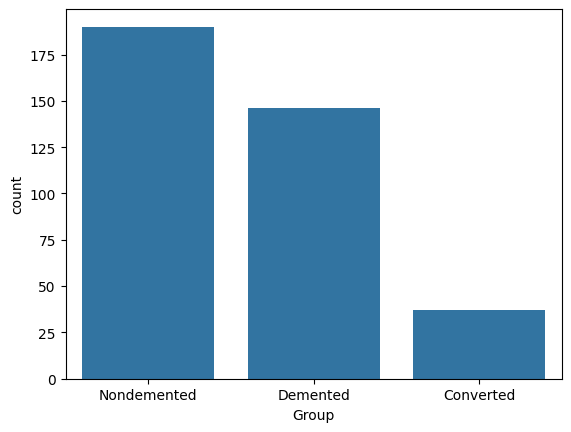

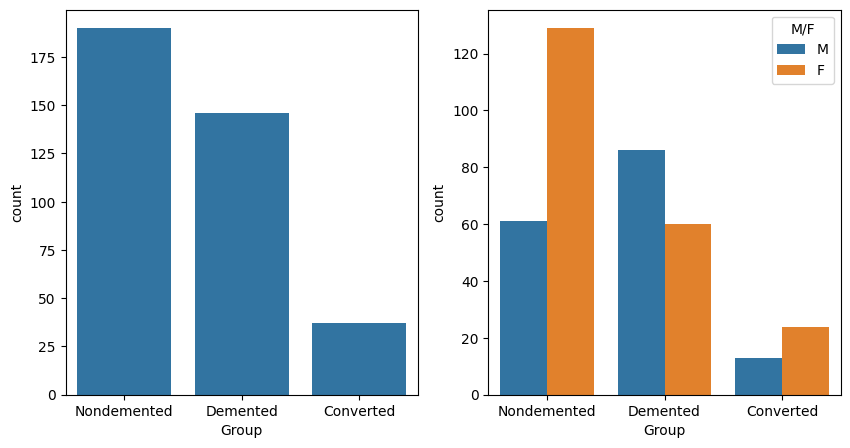

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='Group', data=df)
plt.show()
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.countplot(x='Group', data=df)
plt.subplot(1, 2, 2)
sns.countplot(x='Group', hue='M/F', data=df)
plt.show()

## Boxplot variables numericas

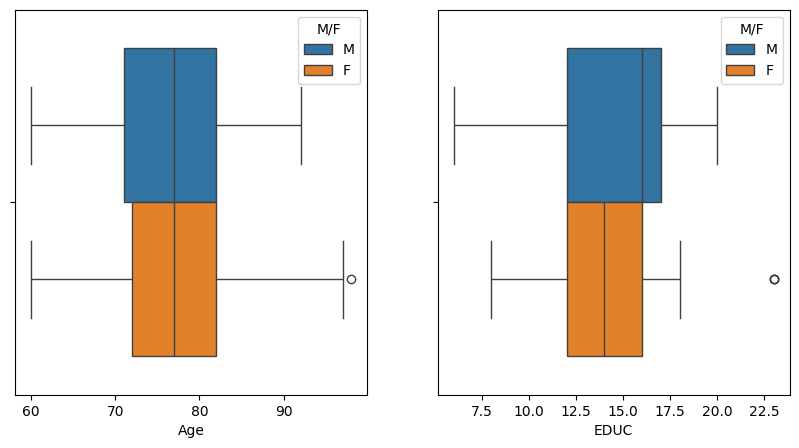

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x='Age', hue='M/F', data=df)
plt.subplot(1, 2, 2)
sns.boxplot(x='EDUC', hue='M/F', data=df)   
plt.show()

## Correlacion

In [31]:
num_vars = df.select_dtypes(include=['number']).corr()
columnas_numericas = df.select_dtypes(include=['number']).columns
num_vars = df[columnas_numericas].corr()
num_vars


,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
Age,1.000000,-0.027886,-0.046857,0.055612,-0.026257,0.042348,-0.518359,-0.035067
EDUC,-0.027886,1.000000,-0.722647,0.194884,-0.153121,0.257015,-0.012200,-0.241752
SES,-0.046857,-0.722647,1.000000,-0.149219,0.076160,-0.261575,0.090095,0.255576
MMSE,0.055612,0.194884,-0.149219,1.000000,-0.686519,-0.032084,0.341912,0.040052
CDR,-0.026257,-0.153121,0.076160,-0.686519,1.000000,0.022819,-0.344819,-0.029340
eTIV,0.042348,0.257015,-0.261575,-0.032084,0.022819,1.000000,-0.210122,-0.988877
nWBV,-0.518359,-0.012200,0.090095,0.341912,-0.344819,-0.210122,1.000000,0.213476
ASF,-0.035067,-0.241752,0.255576,0.040052,-0.029340,-0.988877,0.213476,1.000000


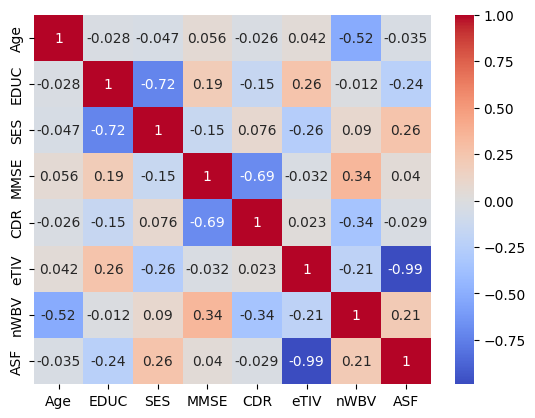

In [32]:
sns.heatmap(num_vars, annot=True, cmap='coolwarm')
plt.show()

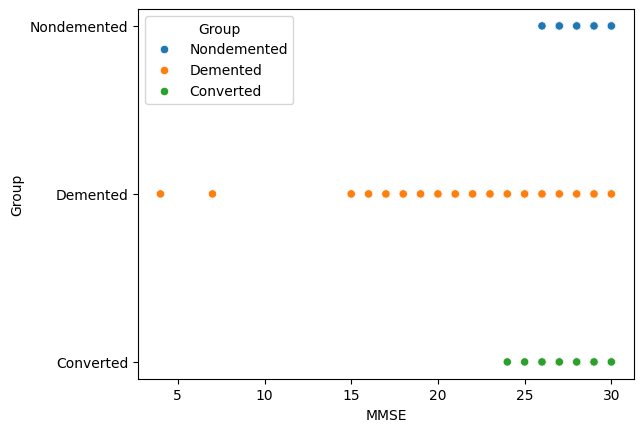

In [35]:
sns.scatterplot(data=df, x='MMSE', y='Group', hue='Group')
plt.show()


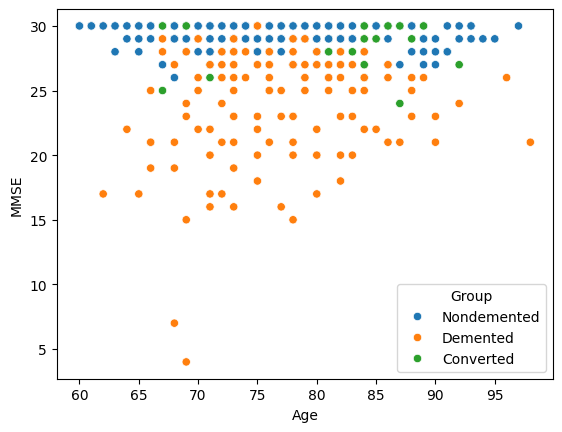

In [ ]:
sns.scatterplot(x='Age', y='MMSE', hue='Group', data=df)
plt.show()

In [52]:
from sklearn.impute import KNNImputer
from pandas import DataFrame

In [47]:
x = df.drop(columns=['Group'])
y = df['Group']

In [ ]:
knn_inp = KNNImputer(n_neighbors=5, weights='distance')
x_numeric = x.drop(columns=['M/F'])
x_imputed = knn_inp.fit_transform(x_numeric)
x_imputed_df = pd.DataFrame(x_imputed, columns=x_numeric.columns, index=x.index)
x_imputed_df['M/F'] = x['M/F']
x_imputed_df

,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF,M/F
0,87.0,14.0,2.000000,27.0,0.0,1987.0,0.696,0.883,M
1,88.0,14.0,2.000000,30.0,0.0,2004.0,0.681,0.876,M
2,75.0,12.0,1.981267,23.0,0.5,1678.0,0.736,1.046,M
3,76.0,12.0,2.761288,28.0,0.5,1738.0,0.713,1.010,M
4,80.0,12.0,2.266564,22.0,0.5,1698.0,0.701,1.034,M
...,...,...,...,...,...,...,...,...,...
368,82.0,16.0,1.000000,28.0,0.5,1693.0,0.694,1.037,M
369,86.0,16.0,1.000000,26.0,0.5,1688.0,0.675,1.040,M
370,61.0,13.0,2.000000,30.0,0.0,1319.0,0.801,1.331,F
371,63.0,13.0,2.000000,30.0,0.0,1327.0,0.796,1.323,F


In [63]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

In [67]:
x_train, x_test, y_train, y_test = train_test_split(x_imputed_df, y, test_size=0.2, random_state=42)
pipeline = Pipeline(steps=[
    ("imputer", KNNImputer(n_neighbors=5, weights='distance')),
    ("scaler", StandardScaler()),   
    ("pca", PCA(n_components=2)),
    ("classifier", KNeighborsClassifier(n_neighbors=5, weights='distance'))
])
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan or None, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`should be set to np.nan, since `pd.NA` will be converted to np.nan.",nan
,"n_neighbors n_neighbors: int, default=5Number of neighboring samples to use for imputation.",5
,"weights weights: {'uniform', 'distance'} or callable, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- callable : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.",'distance'
,"metric metric: {'nan_euclidean'} or callable, default='nan_euclidean'Distance metric for searching neighbors. Possible values:- 'nan_euclidean'- callable : a user-defined function which conforms to the definition of ``func_metric(x, y, *, missing_values=np.nan)``. `x` and `y` corresponds to a row (i.e. 1-D arrays) of `X` and `Y`, respectively. The callable should returns a scalar distance value.",'nan_euclidean'
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto theoutput of the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear on themissing indicator even if there are missing values at transform/testtime.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0`... versionadded:: 1.2",Fal

In [ ]:
metrics = cross_val_score(pipeline cv=5, scoring='accuracy')
print(metrics)